# 🪟 **Reading by Windows & Decimation**

> ### 📌 **TL;DR**
>
> This Jupyter notebook has been created to compare different features with several open source Python libraries for rasters management.
>
> This notebook explores windowed reading and raster decimation mechanisms across several libraries.
>
> A special focus will be on how chunked/dask-backed execution is supported for each workflow.
>
> The following libraries will be considered :
>- `rasterio`
>- `rioxarray`
>- `odc-geo`
>- `geoutils`
>- `xarray-spatial`

In [ ]:
import rasterio
from rasterio.windows import Window
from rasterio.plot import show
from rasterio.enums import Resampling

import rioxarray as rxr

import xrspatial as xrs
from xrspatial.geotiff import open_geotiff
from xrspatial.preview import preview

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn # cmap mako

In [2]:
# path to the raster object
raster_path = "../data/rasters/105005005BDEA700-visual.tif"

## **Reading by Windows**

A *Window* is a rectangular subset of a raster, defined by pixels coordinates (rows/ columns).

It is particularly useful for reading or writing big rasters, without having to load the full raster in-memory, but also to speed up processing times.

This feature is available through `rasterio`, `rioxarray`, `xarray-spatial` and with a workaround in `geoutils`.

### • *rasterio*

In [3]:
ds_rasterio = rasterio.open(raster_path)

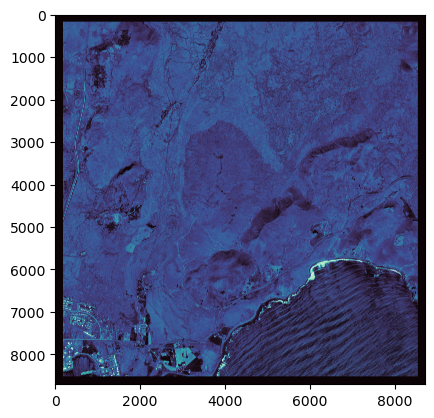

<Axes: >

In [4]:
show(ds_rasterio.read(1), cmap="mako")

With `rasterio`, a specific module is dedicated to [`Windows`](https://rasterio.readthedocs.io/en/stable/api/rasterio.windows.html).

In the following case, we will create a subset of our image with `1500 rows x 1500 columns`. When initializing our `Window`, we will specify its size (*width* and *height*) and the position of the top-left pixel where to start creating it.

In [6]:
window = Window(col_off=1500, row_off=1500, width=1500, height=1500)

We will focus on the first band for our example.

We first create an object `w` that represents a subset of our image. Then, we specify the [`window`argument to the `.read` function](https://rasterio.readthedocs.io/en/stable/topics/windowed-rw.html#reading) to select the extent of our `Window` object previously created. `rasterio` performs *eager* I/O operations - the `.read(window=...)` call will immediately loads data into memory.

In [7]:
b1 = ds_rasterio.read(1)

w = ds_rasterio.read(1, window=window)

Let's now compare the full raster with the subset image created with the `Window`'s extents :

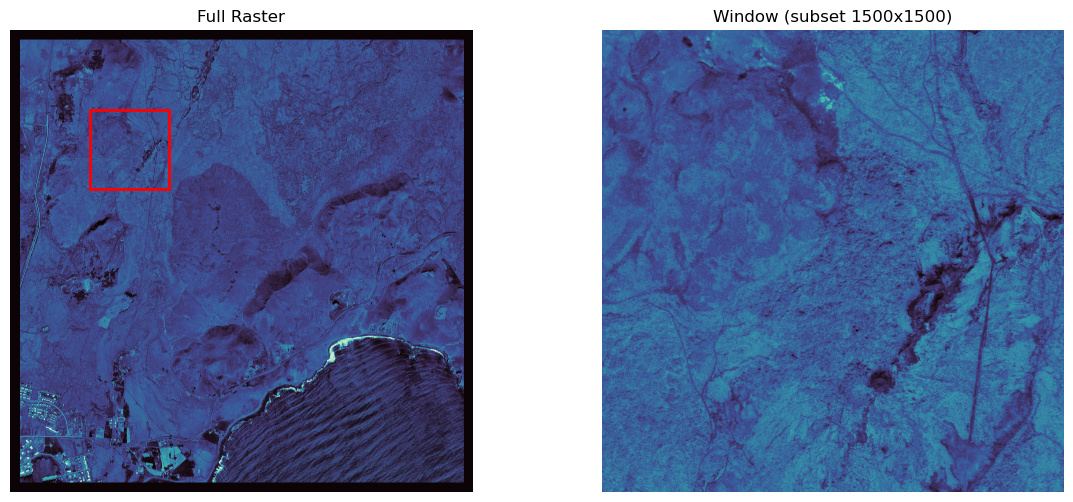

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Full raster
axes[0].imshow(b1, cmap="mako")
axes[0].set_title("Full Raster")
axes[0].axis("off")

# Rectangle
rect = patches.Rectangle(
    (window.col_off, window.row_off),
    window.width,
    window.height,
    linewidth=2, edgecolor='red', facecolor='none'
)
axes[0].add_patch(rect)

# Window raster
axes[1].imshow(w, cmap="mako")
axes[1].set_title("Window (subset 1500x1500)")
axes[1].axis("off")

plt.show()

### • *rioxarray*

The code below opens the raster with `chunks={'x': 2048, 'y': 2048}`. This creates **lazy dask arrays** backed by xarray. The `.isel_window()` operation builds a computational graph but **does not read data yet**. Only when you call `.compute()` or perform I/O operations (like `.plot()` or `.sel()`) will the actual windowed data be loaded.

In [11]:
ds_rioxarray = rxr.open_rasterio(raster_path, chunks={'x': 2048, 'y': 2048})

`rioxarray` has a built-in function to work with windows, namely [`.isel_window()`](https://corteva.github.io/rioxarray/stable/rioxarray.html#rioxarray.rioxarray.XRasterBase.isel_window). It is basically an equivalent of `.read(..., window=)`, seen previously with `rasterio`. If the dataset is chunked, `isel_window` builds a *lazy* `dask` graph and will execute it only when calling `.compute()`.

We will pass our `rasterio.Window` object previously created as an argument (as requested in the documentation of the function) to specify the extents of the new raster :

In [9]:
window

Window(col_off=1500, row_off=1500, width=1500, height=1500)

In [12]:
rxr_subset = ds_rioxarray.rio.isel_window(window)

And here is the result - note that calling `.plot()` or `.show()` automatically triggers computation of the *lazy* `dask` array:

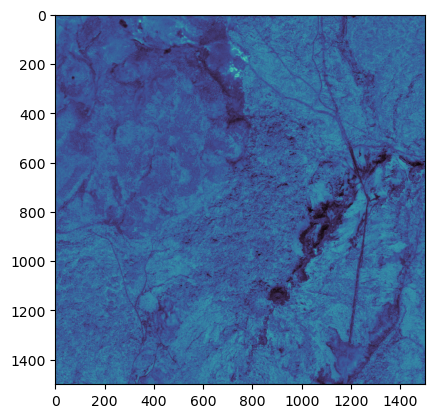

<Axes: >

In [13]:
show(rxr_subset.sel(band=1), cmap="mako")

### • *geoutils*

In `geoutils`, this feature has an [opened issue](https://github.com/GlacioHack/geoutils/issues/583).

Creating a window through `geoutils` uses a different mechanism from other libraries. The right way for that is to open the data object and then use [`.crop()`](https://geoutils.readthedocs.io/en/stable/gen_modules/geoutils.Raster.crop.html#geoutils.Raster.crop) or [`.icrop()`](https://geoutils.readthedocs.io/en/stable/gen_modules/geoutils.Raster.icrop.html#geoutils.Raster.icrop). 

This method is further detailed in the [`mask_and_crop`](https://github.com/sertit/open_source_rasters_comparison/blob/main/notebooks/04_mask_and_crop.ipynb) notebook.

### • *xarray-spatial*

Instead of loading the full raster, `xarray-spatial` supports windowed reading through its built-in function [`.open_geotiff()`](https://xarray-spatial.readthedocs.io/en/stable/reference/_autosummary/xrspatial.geotiff.open_geotiff.html#xrspatial.geotiff.open_geotiff), by using the `window` argument as *(row_start, col_start, row_stop, col_stop)*, where the indices define the pixel range to load.

In the following example, we will create a window with the size of `1500x1500` and starting from the top-left corner of the image. 

Since `xarray-spatial` is also compatible with `dask`, we can pass the `chunks` argument for a dask-backed *lazy* read  :

In [14]:
ds_xrs = open_geotiff(raster_path, chunks=2048, window=(0, 0, 1500, 1500),  allow_internal_only_jpeg=True)

The object returned is then a `xarray.DataArray` :

In [15]:
type(ds_xrs)

xarray.core.dataarray.DataArray

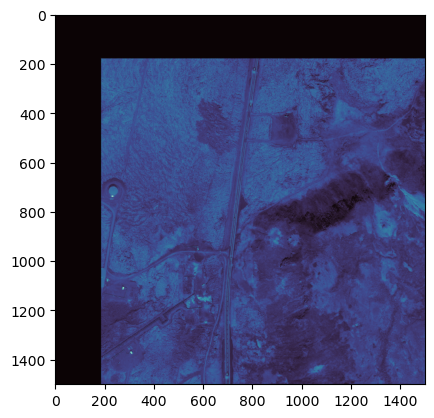

<Axes: >

In [16]:
show(ds_xrs.sel(band=1), cmap="mako")

## **Decimation**

Decimation is used to reduce the image resolution of a raster by skipping a certain amount of pixels in rows, columns or both, or by calculating the average of the surrounding pixels. The method applied depends on the chosen resampling method. By default, `rasterio` uses [`nearest`](https://rasterio.readthedocs.io/en/stable/api/rasterio.enums.html#rasterio.enums.Resampling.nearest), which will take the value of the nearest pixel and "skip" others. `average` will compute the weighted average of all non-nodata contributing pixels, and some other methods will do an interpolation (`bilinear`, `cubic`, `cubic_spline`, `lanczos`, ...).

Decimation is particularly useful to speed up the display without reading all pixels (*pyramids*) or to analyze large raster files when full resolution is not needed.

This feature is possible through `rasterio` and by using a workaround in `rioxarray`.

In `xarray-spatial`, the built-in function `.preview()` is available for this feature.

### • *rasterio*

In the following case, we will reduce the size by half (*height* and *width*). 

Our raster's size is `8705 x 8705`, so we want to reshape it as `4352 x 4352`. 

We can do so by using the [`.read()`](https://rasterio.readthedocs.io/en/stable/api/rasterio.io.html#rasterio.io.BufferedDatasetWriter.read) function, but we will use the `out_shape` argument to select the extent we want to keep, which is quite straight-forward :

In [17]:
decimated_b1 = ds_rasterio.read(1, out_shape=(4352, 4352))

We can now plot the decimated raster :

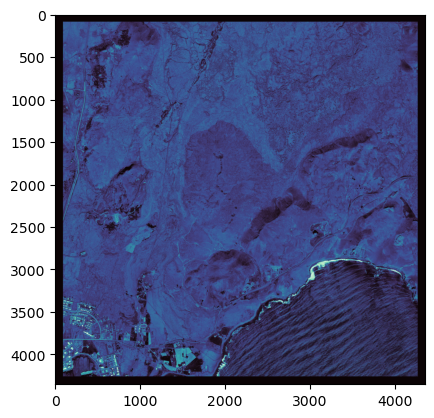

<Axes: >

In [18]:
show(decimated_b1, cmap="mako")

We can finally validate the new shape with the `shape` attribute as follows :

In [19]:
decimated_b1.shape

(4352, 4352)

### • *rioxarray*

There is no trivial method to decimate an image through `xarray` and especially `rioxarray`, unlike `rasterio`.

To do so, we first have to `reproject` it and then use a `resampling` algorithm, as explained below. Importantly, when opening with **chunks**, the `.reproject()` operation becomes **lazy**, allowing dask to manage the decimation efficiently without loading the full raster into memory first.

In [21]:
ds_rxr = rxr.open_rasterio(raster_path, chunks={'x': 2048, 'y': 2048})

Here we specify our new wanted resolution. We will multiply it by 2, so the final size of our raster will be divided by 2.

Since the dataset is chunked, the following `.reproject()` operation will build a lazy dask computational graph. No actual resampling happens until you call `.compute()` or trigger a computation with `.plot()`, `.to_netcdf()`, etc.

In [22]:
new_res = (
    ds_rxr.rio.resolution()[0] * 2,
    ds_rxr.rio.resolution()[1] * 2
)

Finally, we will use [`.reproject()`](https://corteva.github.io/rioxarray/stable/rioxarray.html#rioxarray.raster_array.RasterArray.reproject) and we specify the original CRS, the new resolution and the resampling method (`bilinear` here) :

In [23]:
rxr_decimated = ds_rxr.rio.reproject(
    ds_rxr.rio.crs,
    resolution=new_res,
    resampling=Resampling.bilinear
)

We can finally plot the new map :

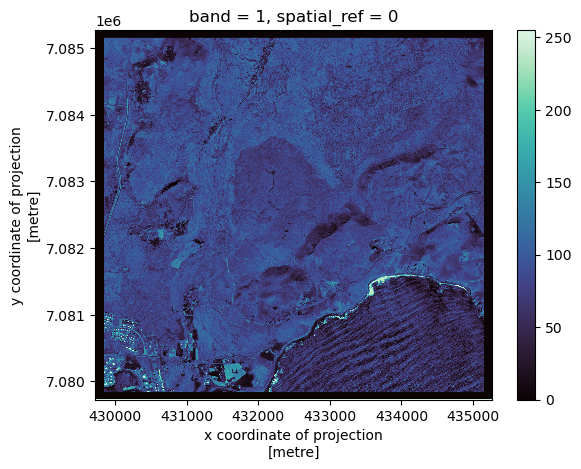

In [26]:
rxr_decimated.sel(band=1).plot(cmap="mako")

Once again, we can make sure the shape of the new image is correct :

In [27]:
print(f"Size : {rxr_decimated.rio.width} x {rxr_decimated.rio.height}")

Size : 4353 x 4353


### • *xarray-spatial*

`xarray-spatial` provides a convenient way to create a downsampled version of an `xarray.DataArray` for visualization purposes, through its [`.preview()`](https://xarray-spatial.readthedocs.io/en/stable/reference/_autosummary/xrspatial.preview.preview.html#xrspatial.preview.preview) function.

It will automatically reduce the raster resolution to a target size by specifying the desired *width* and *height*.

This function can also be used with `dask`, making it useful for reading large rasters :
> For dask-backed arrays, the operation is lazy: each chunk is reduced independently, so peak memory is bounded by the largest chunk plus the small output array. A 30 TB raster can be previewed at 1000x1000 with only a few MB of RAM.

Here is an example on how to use it :

In [28]:
ds_xrs = open_geotiff(raster_path, chunks=2048, allow_internal_only_jpeg=True)

In [29]:
ds_xrs.shape

(8705, 8705, 3)

Our raster's current shape is `8705 x 8705`, as for previous examples, we will reshape it to `4352 x 4352`.

In [ ]:
# Selecting the first band
ds_xrs_b1 = ds_xrs.isel(band=0)

Then we will use the `.preview()` function specifying our *width* and *height*, as follows :

In [32]:
ds_xrs_preview = preview(ds_xrs_b1, width=4352, height=4352)

In [33]:
ds_xrs_preview.shape

(4352, 4352)